In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Each neuron: laser_mod_index <--> left_right_tone_index, left_right_lick_index, reward_index

- tone: 25 ms
- reward is delivered as soon as the first selection lick is detected
- ENL: 1500 + np.ranodom(0,500)

## 1. Load the data from folder

In [2]:
# import tkinter as tk
# from tkinter import filedialog
# # Hide the main tkinter window
# root = tk.Tk()
# root.withdraw()

# # Open a dialog to select the session folder
# base_folder = filedialog.askdirectory(title="Select session folder", initialdir=r"/Users/shunli/Downloads/sabalab/forPaolo")
# # Extract the session_id from the selected folder name
# session_id = os.path.basename(base_folder)
# print(f"Selected session_id: {session_id}")
# print(f"Base folder: {base_folder}")

In [3]:
# Hard loading

base_folder = rf"/Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"

# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"
# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250323_5mW_500ms_500delay_032325001"
# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250328_Licking_032825001"

# Extract the session_id from the last part of the path
session_id = os.path.basename(base_folder)
print(f"Selected session_id: {session_id}")

Selected session_id: Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001


In [4]:
# Load data from hdf5 file
# Define data structures
data, trial_table, event_times, metadata = {}, {}, {}, {}
aligned_trial_start, aligned_choice_lick, aligned_second_lick, aligned_last_lick = {}, {}, {}, {}
_open_h5 = {}

data_path = base_folder + "/results-250820/data.h5"
data = ndap.load_session_data(data_path)

trial_table = ndap.load_dataframe(data_path, key='trial_table')
event_times = data['event_times']
metadata = data['metadata']

# Load aligned spikes
spikes_path = base_folder + "/results-250820/aligned_spikes.h5"
aligned_spikes = ndap.load_aligned_spikes(spikes_path)

aligned_trial_start = aligned_spikes['trial_start']
aligned_choice_lick = aligned_spikes['choice_lick']
aligned_second_lick = aligned_spikes['second_lick']
aligned_last_lick = aligned_spikes['last_lick']

time_range = tuple(map(float, metadata['time_range'].strip('()').split(',')))
bin_size = metadata['bin_size']
xaxis = ndap.get_time_axis(time_range, bin_size_ms=bin_size)
print(f"Time range: {time_range}, Bin size: {bin_size}")

DataFrame loaded from /Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Variables loaded from /Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Variables loaded from /Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Session data loaded from /Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
DataFrame loaded from /Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/data.h5
Aligned spikes loaded from /Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/results-250820/aligned_spikes.h5 (lazy=True)
Time range: (-1.0, 2.0), Bin size: 25


## 2. Get modulation index

- Tone
- Choice lick (left vs right encoding)
- reward
- laser

In [5]:
mod_index_type = 'norm'

# ----------------------------- Tone -----------------------------
response_window = (0, 50)   # start at 10 ms, end at 200 ms

tone_rates = ndap.combine_rates(aligned_trial_start, key=['control'])
ctrl_rates = ndap.combine_rates(aligned_trial_start, key=['control'])
tone_rates = ndap.get_window(tone_rates, onset_time=0, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
ctrl_rates = ndap.get_window(ctrl_rates, onset_time=0, window_ms=(-75,-25), bin_size_ms=bin_size, xaxis=xaxis)
tone_mod_index = ndap.get_mod_index(tone_rates, ctrl_rates, type=mod_index_type)


# ----------------------------- Choice (left vs right encoding) -----------------------------
response_window = (0, 75)   # start at 10 ms, end at 200 ms

left_rates = ndap.combine_rates(aligned_choice_lick, key=['left','control'])
right_rates = ndap.combine_rates(aligned_choice_lick, key=['right','control'])
left_rates = ndap.get_window(left_rates, onset_time=0, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
right_rates = ndap.get_window(right_rates, onset_time=0, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
choice_mod_index = ndap.get_mod_index(left_rates, right_rates, type=mod_index_type)


# ----------------------------- Motor -----------------------------
response_window = (0, 100)   # start at 10 ms, end at 200 ms

lick_rates = ndap.combine_rates(aligned_last_lick, key=['control'])
ctrl_rates = ndap.combine_rates(aligned_last_lick, key=['control'])
lick_rates = ndap.get_window(lick_rates, onset_time=0, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
ctrl_rates = ndap.get_window(ctrl_rates, onset_time=0, window_ms=(150,250), bin_size_ms=bin_size, xaxis=xaxis)
motor_mod_index = ndap.get_mod_index(lick_rates, ctrl_rates, type=mod_index_type)


# ----------------------------- Reward -----------------------------
response_window = (0, 200)   # start at 10 ms, end at 200 ms

reward_rates = ndap.combine_rates(aligned_second_lick, key=['reward','control'])
nonreward_rates = ndap.combine_rates(aligned_second_lick, key=['nonreward','control'])
reward_rates = ndap.get_window(reward_rates, onset_time=0, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
nonreward_rates = ndap.get_window(nonreward_rates, onset_time=0, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
reward_mod_index = ndap.get_mod_index(reward_rates, nonreward_rates, type=mod_index_type)


# ----------------------------- Laser -----------------------------
laser_onset = 1.0                   # in sec
response_window = (10, 200)   # start at 10 ms, end at 200 ms

laser_rates = ndap.combine_rates(aligned_trial_start, key=['laser'])
control_rates = ndap.combine_rates(aligned_trial_start, key=['control'])
laser_rates = ndap.get_window(laser_rates, onset_time=laser_onset, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
control_rates = ndap.get_window(control_rates, onset_time=laser_onset, window_ms=response_window, bin_size_ms=bin_size, xaxis=xaxis)
laser_mod_index = ndap.get_mod_index(laser_rates, control_rates, type=mod_index_type)


# ----------------------------- Convert to numpy array -----------------------------
tone_mod_index = ndap.convert_dask_to_numpy(tone_mod_index)
choice_mod_index = ndap.convert_dask_to_numpy(choice_mod_index)
motor_mod_index = ndap.convert_dask_to_numpy(motor_mod_index)
reward_mod_index = ndap.convert_dask_to_numpy(reward_mod_index)
laser_mod_index = ndap.convert_dask_to_numpy(laser_mod_index)


# ----------------------------- Print top 5 excited and suppressed neurons -----------------------------
idx_excited = np.argsort(tone_mod_index)[-5:][::-1]
idx_supp    = np.argsort(tone_mod_index)[:5]
print("Top 5 excited neurons by tone:", idx_excited, tone_mod_index[idx_excited])
print("Top 5 suppressed neurons by tone:", idx_supp, tone_mod_index[idx_supp])

idx_excited = np.argsort(choice_mod_index)[-5:][::-1]
idx_supp    = np.argsort(choice_mod_index)[:5]
print("Top 5 excited neurons by choice:", idx_excited, choice_mod_index[idx_excited])
print("Top 5 suppressed neurons by choice", idx_supp, choice_mod_index[idx_supp])

idx_excited = np.argsort(motor_mod_index)[-5:][::-1]
idx_supp    = np.argsort(motor_mod_index)[:5]
print("Top 5 excited neurons by motor:", idx_excited, motor_mod_index[idx_excited])
print("Top 5 suppressed neurons by motor:", idx_supp, motor_mod_index[idx_supp])

idx_excited = np.argsort(reward_mod_index)[-5:][::-1]
idx_supp    = np.argsort(reward_mod_index)[:5]
print("Top 5 excited neurons by reward:", idx_excited, reward_mod_index[idx_excited])
print("Top 5 suppressed neurons by reward:", idx_supp, reward_mod_index[idx_supp])

idx_excited = np.argsort(laser_mod_index)[-5:][::-1]
idx_supp    = np.argsort(laser_mod_index)[:5]
print("Top 5 excited neurons by laser:", idx_excited, laser_mod_index[idx_excited])
print("Top 5 suppressed neurons by laser:", idx_supp, laser_mod_index[idx_supp])


Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'nonreward_right_control']
Combining 4 conditions: ['nonreward_left_laser', 'nonreward_right_laser', 'reward_left_laser', 'reward_right_laser']
Combining 4 conditions: ['nonr

### 2.3. Plot modulation index

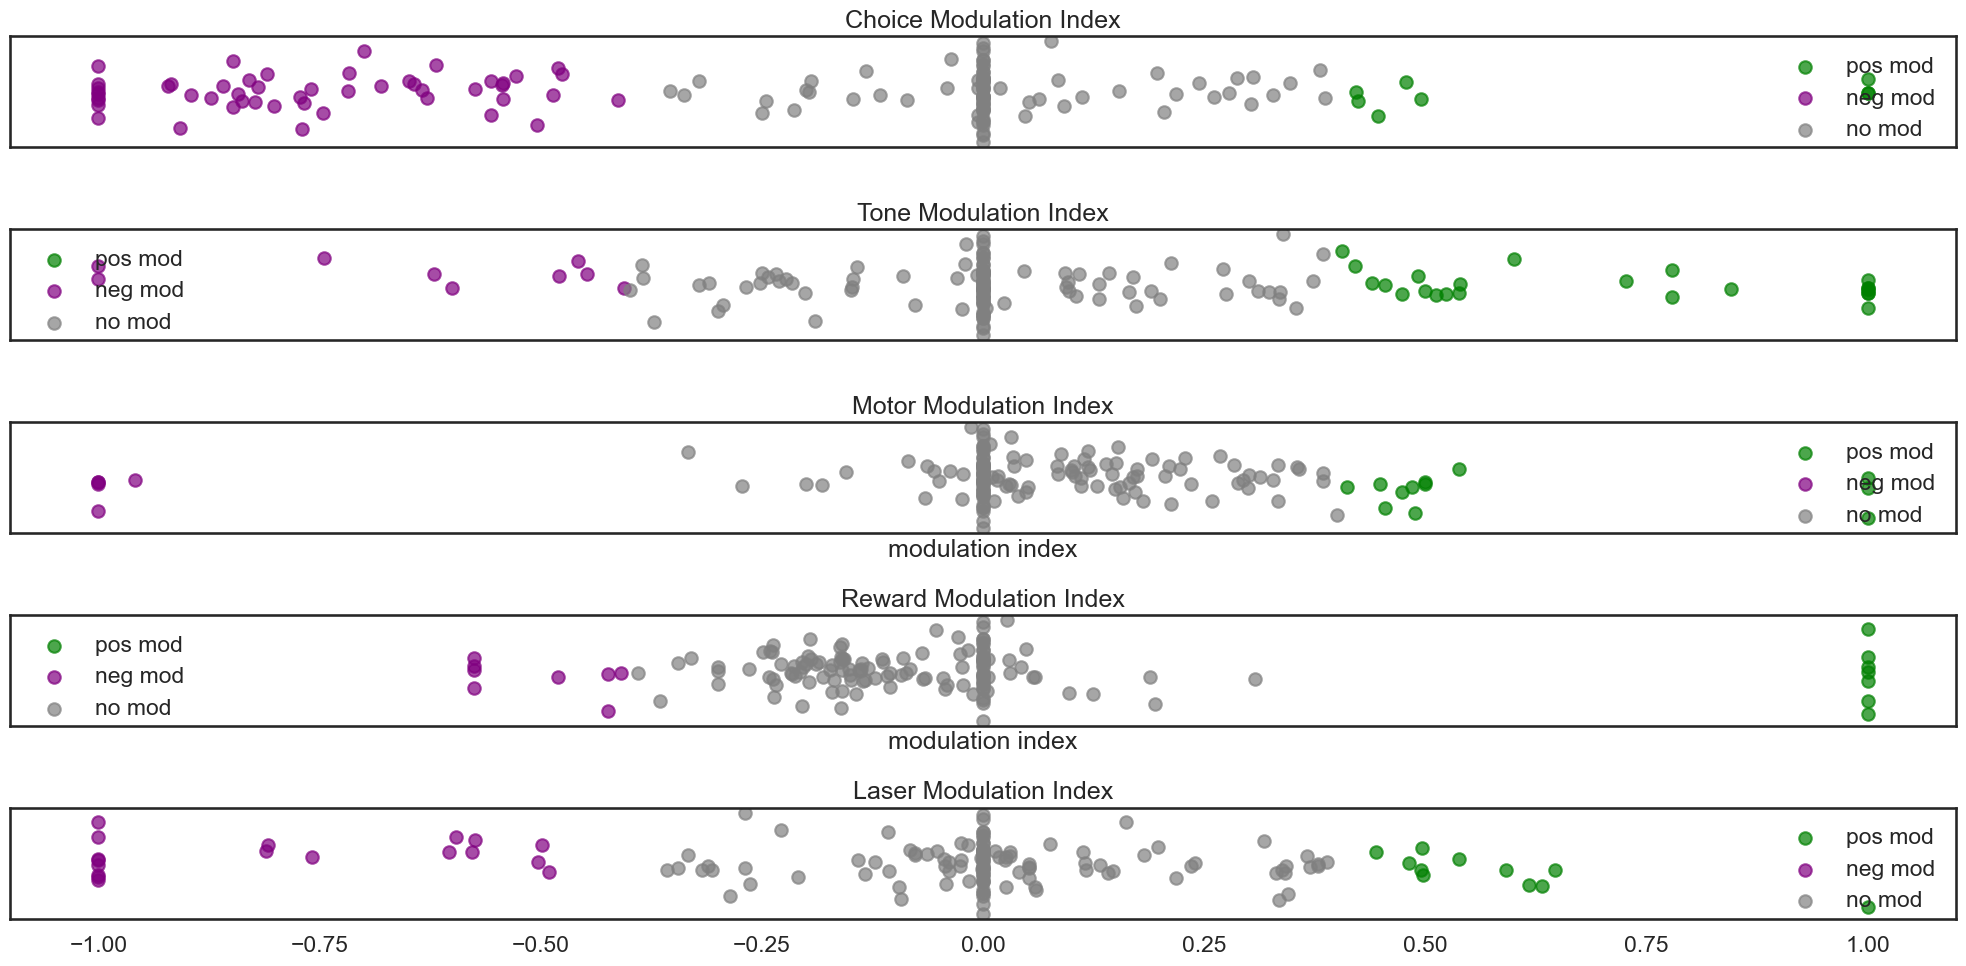

In [6]:
# Plot and group all modulation indices in a 2x2 grid of subplots
mod_indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index),
    ("Laser Modulation Index", laser_mod_index)
]

fig, axes = plt.subplots(len(mod_indices), 1, figsize=(20, 10), sharex=True)

# Flatten axes for easy iteration
axes_flat = axes.flatten()

# Use the same y_jitter for all plots, based on the number of units (assume all mod indices have same length)
y_jitter = np.random.normal(loc=0, scale=0.1, size=laser_mod_index.size)

pos_mod_color = 'green'
neg_mod_color = 'purple'
no_mod_color = 'gray'
th = 0.4

for ax, (title, mod_index) in zip(axes_flat, mod_indices):
    pos_mask = mod_index > th
    neg_mask = mod_index < -th
    no_mask  = (~pos_mask & ~neg_mask)
    ax.scatter(mod_index[pos_mask], y_jitter[pos_mask],
               color=pos_mod_color, alpha=0.7, label='pos mod')
    ax.scatter(mod_index[neg_mask], y_jitter[neg_mask],
               color=neg_mod_color, alpha=0.7, label='neg mod')
    ax.scatter(mod_index[no_mask],  y_jitter[no_mask],
               color=no_mod_color,  alpha=0.7, label='no mod')
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_title(title)
    ax.legend(frameon=False)

# Set xlabel only for bottom row
for i, ax in enumerate(axes_flat):
    if i // 2 == 1:  # bottom row
        ax.set_xlabel('modulation index')

plt.tight_layout()

/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_837/642381697.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


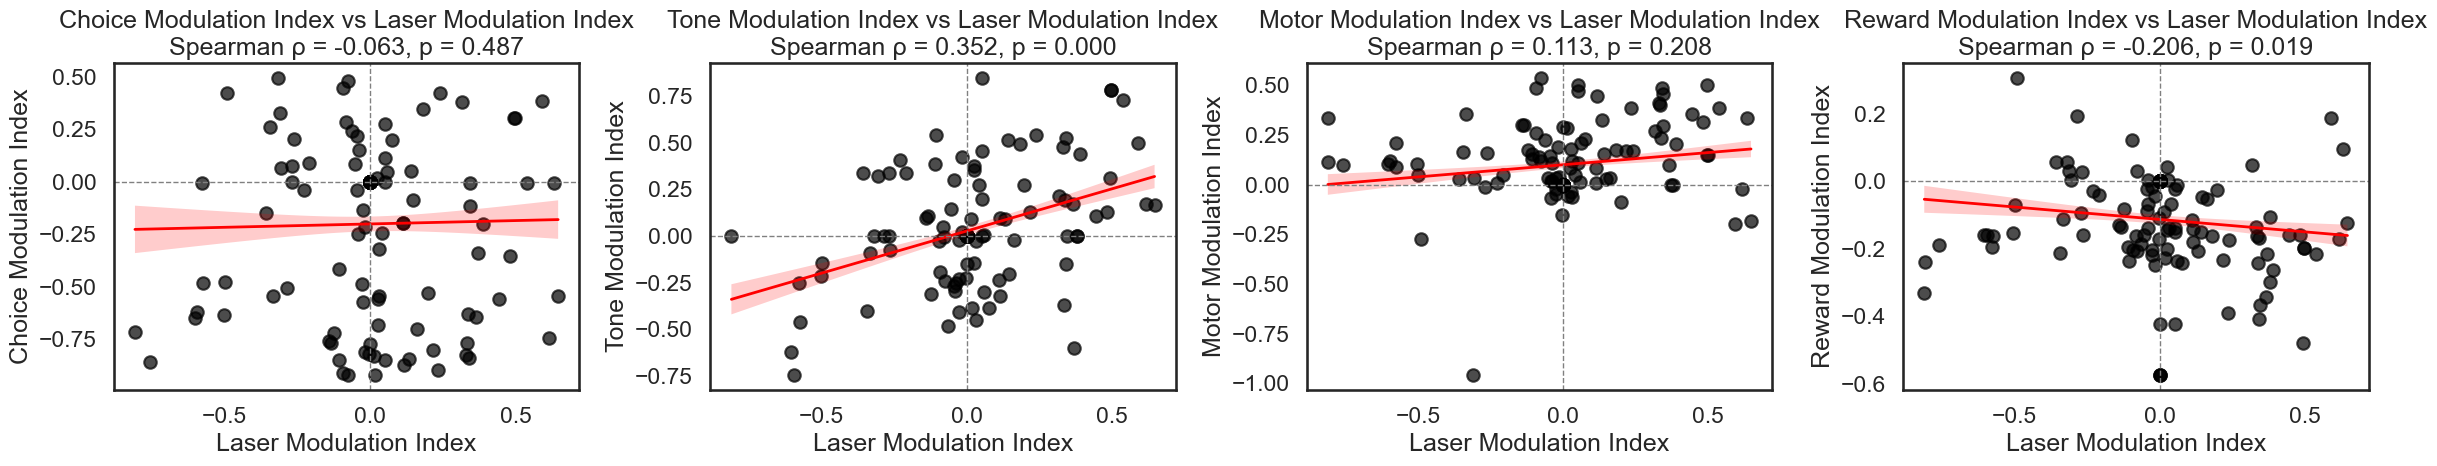

In [7]:
# Three scatter plots: laser_mod_index (x) vs other indices (y), 1 row x 3 columns, with best fit line and Spearman correlation
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index)
]

for ax, (title, y_index) in zip(axes, indices):
    # Remove indices of 1 and -1
    tol = 1e-8
    mask = ~(
        np.isclose(np.abs(laser_mod_index), 1.0, atol=tol) |
        np.isclose(np.abs(y_index), 1.0, atol=tol)
    )
    laser_mod_index_clean = laser_mod_index[mask]
    y_index_clean = y_index[mask]

    # Scatter plot
    ax.scatter(laser_mod_index_clean, y_index_clean, color='black', alpha=0.7)
    # Best fit line (linear regression)
    m, b = np.polyfit(laser_mod_index_clean, y_index_clean, 1)
    x_fit = np.linspace(np.min(laser_mod_index_clean), np.max(laser_mod_index_clean), 100)
    y_fit = m * x_fit + b

    # Calculate SEM of the fit line
    # For each x_fit, compute predicted y, then SEM of residuals
    y_pred = m * laser_mod_index_clean + b
    residuals = y_index_clean - y_pred
    # Standard error of the regression (residuals)
    n = len(laser_mod_index_clean)
    if n > 2:
        s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    else:
        s_err = np.nan

    # For each x_fit, calculate SEM of the fit line
    x_mean = np.mean(laser_mod_index_clean)
    Sxx = np.sum((laser_mod_index_clean - x_mean) ** 2)
    if Sxx > 0 and n > 2:
        sem_fit = s_err * np.sqrt(1/n + (x_fit - x_mean)**2 / Sxx)
    else:
        sem_fit = np.full_like(x_fit, np.nan)

    ax.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2)
    ax.fill_between(x_fit, y_fit - sem_fit, y_fit + sem_fit, color='red', alpha=0.2, edgecolor='None')

    # Spearman correlation
    rho, pval = spearmanr(laser_mod_index_clean, y_index_clean)
    ax.set_xlabel('Laser Modulation Index')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Laser Modulation Index\nSpearman ρ = {rho:.3f}, p = {pval:.3f}')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Laser modulation index: -0.5738784068772274
Tone modulation index: -0.4576271186439274
Choice modulation index: -0.48069980560953457
Reward modulation index: -0.16117673235239813


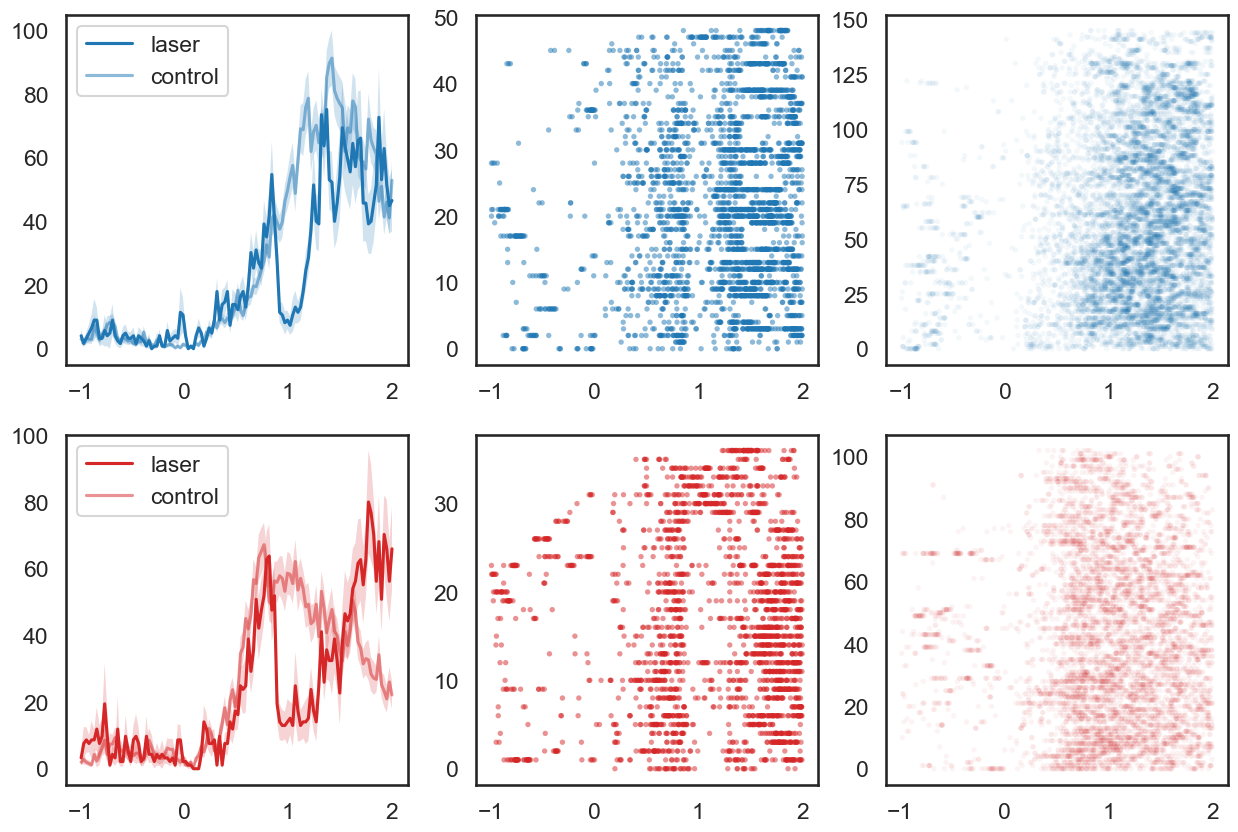

In [8]:
# Plot firing rate per neuron
# 73: high firing, 23, 67, 37: modulated
fig, ax = plt.subplots(2,3,figsize=(15,10))
unit_id = 67

left_color   = 'tab:blue'
right_color  = 'tab:red'
alpha_ctrl   = 0.5
alpha_laser  = 1.0

aligned = aligned_trial_start

# Row 0: left trials
ndap.plot_sem(aligned['reward_left_laser']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_laser, plot_individual=False, ax=ax[0,0], label='laser')
ndap.plot_sem(aligned['reward_left_control']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[0,0], label='control')
ax[0,0].legend()
ndap.plot_raster(aligned['reward_left_laser']['times'][unit_id], x=xaxis, color=left_color, alpha=0.5*alpha_laser, ax=ax[0,1])
ndap.plot_raster(aligned['reward_left_control']['times'][unit_id], x=xaxis, color=left_color, alpha=0.1*alpha_ctrl, ax=ax[0,2])

# Row 1: right trials
ndap.plot_sem(aligned['reward_right_laser']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_laser, plot_individual=False, ax=ax[1,0], label='laser')
ndap.plot_sem(aligned['reward_right_control']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[1,0], label='control')
ax[1,0].legend()
ndap.plot_raster(aligned['reward_right_laser']['times'][unit_id], x=xaxis, color=right_color, alpha=0.5*alpha_laser, ax=ax[1,1])
ndap.plot_raster(aligned['reward_right_control']['times'][unit_id], x=xaxis, color=right_color, alpha=0.1*alpha_ctrl, ax=ax[1,2])


print('Laser modulation index: ' + str(laser_mod_index[unit_id]))
print('Tone modulation index: ' + str(tone_mod_index[unit_id]))
print('Choice modulation index: ' + str(choice_mod_index[unit_id]))
print('Reward modulation index: ' + str(reward_mod_index[unit_id]))

## 3. Plot trajectory aligned to events

In [9]:
# combine left and right data
criteria = None
aligned = aligned_trial_start

left_rates_control = ndap.combine_rates(aligned, key=['left','control'])
right_rates_control = ndap.combine_rates(aligned, key=['right','control'])
left_rates_laser = ndap.combine_rates(aligned, key=['left','laser'])
right_rates_laser = ndap.combine_rates(aligned, key=['right','laser'])

if criteria is not None:
    left_rates_control = left_rates_control[criteria, :, :]
    right_rates_control = right_rates_control[criteria, :, :]
    left_rates_laser = left_rates_laser[criteria, :, :]
    right_rates_laser = right_rates_laser[criteria, :, :]

left_color   = 'tab:blue'
right_color  = 'tab:red'
alpha_ctrl   = 0.3
alpha_laser  = 1.0

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_laser', 'reward_left_laser']
Combining 2 conditions: ['nonreward_right_laser', 'reward_right_laser']


### 3.1. Plot projection onto CD_choice

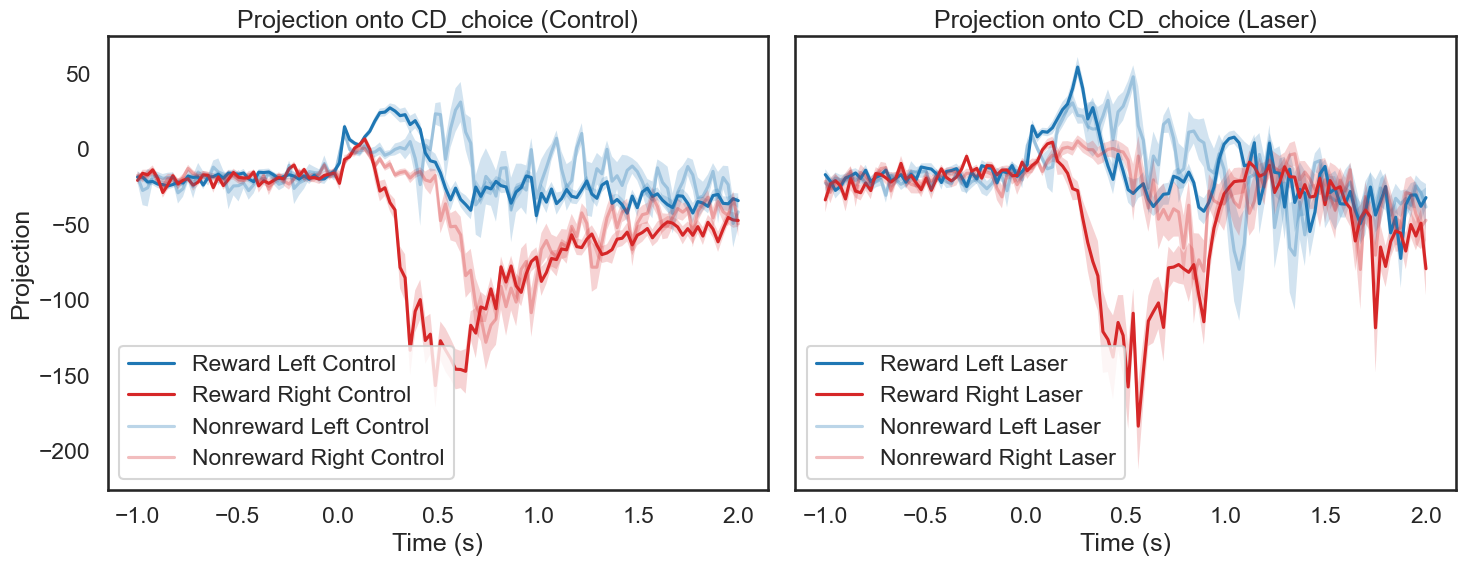

In [10]:
cd_choice = ndap.get_mod_index(left_rates, right_rates, type='cd')
aligned = aligned_trial_start

# Get projections for control
proj_reward_left_control = ndap.project(aligned['reward_left_control']['rate'], cd=cd_choice)
proj_reward_right_control = ndap.project(aligned['reward_right_control']['rate'], cd=cd_choice)
proj_nonreward_left_control = ndap.project(aligned['nonreward_left_control']['rate'], cd=cd_choice)
proj_nonreward_right_control = ndap.project(aligned['nonreward_right_control']['rate'], cd=cd_choice)

# Get projections for laser
proj_reward_left_laser = ndap.project(aligned['reward_left_laser']['rate'], cd=cd_choice)
proj_reward_right_laser = ndap.project(aligned['reward_right_laser']['rate'], cd=cd_choice)
proj_nonreward_left_laser = ndap.project(aligned['nonreward_left_laser']['rate'], cd=cd_choice)
proj_nonreward_right_laser = ndap.project(aligned['nonreward_right_laser']['rate'], cd=cd_choice)

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
# Left: Control
ndap.plot_sem(proj_reward_left_control, x=xaxis, color=left_color, alpha=alpha_laser, label='Reward Left Control', ax=axs[0])
ndap.plot_sem(proj_reward_right_control, x=xaxis, color=right_color, alpha=alpha_laser, label='Reward Right Control', ax=axs[0])
ndap.plot_sem(proj_nonreward_left_control, x=xaxis, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Control', ax=axs[0])
ndap.plot_sem(proj_nonreward_right_control, x=xaxis, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Control', ax=axs[0])
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Projection')
axs[0].set_title('Projection onto CD_choice (Control)')
axs[0].legend()

# Right: Laser
ndap.plot_sem(proj_reward_left_laser, x=xaxis, color=left_color, alpha=alpha_laser, label='Reward Left Laser', ax=axs[1])
ndap.plot_sem(proj_reward_right_laser, x=xaxis, color=right_color, alpha=alpha_laser, label='Reward Right Laser', ax=axs[1])
ndap.plot_sem(proj_nonreward_left_laser, x=xaxis, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Laser', ax=axs[1])
ndap.plot_sem(proj_nonreward_right_laser, x=xaxis, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Laser', ax=axs[1])
axs[1].set_xlabel('Time (s)')
axs[1].set_title('Projection onto CD_choice (Laser)')
axs[1].legend()

plt.tight_layout()
plt.show()


### 3.2. Plot PCA trajectory

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


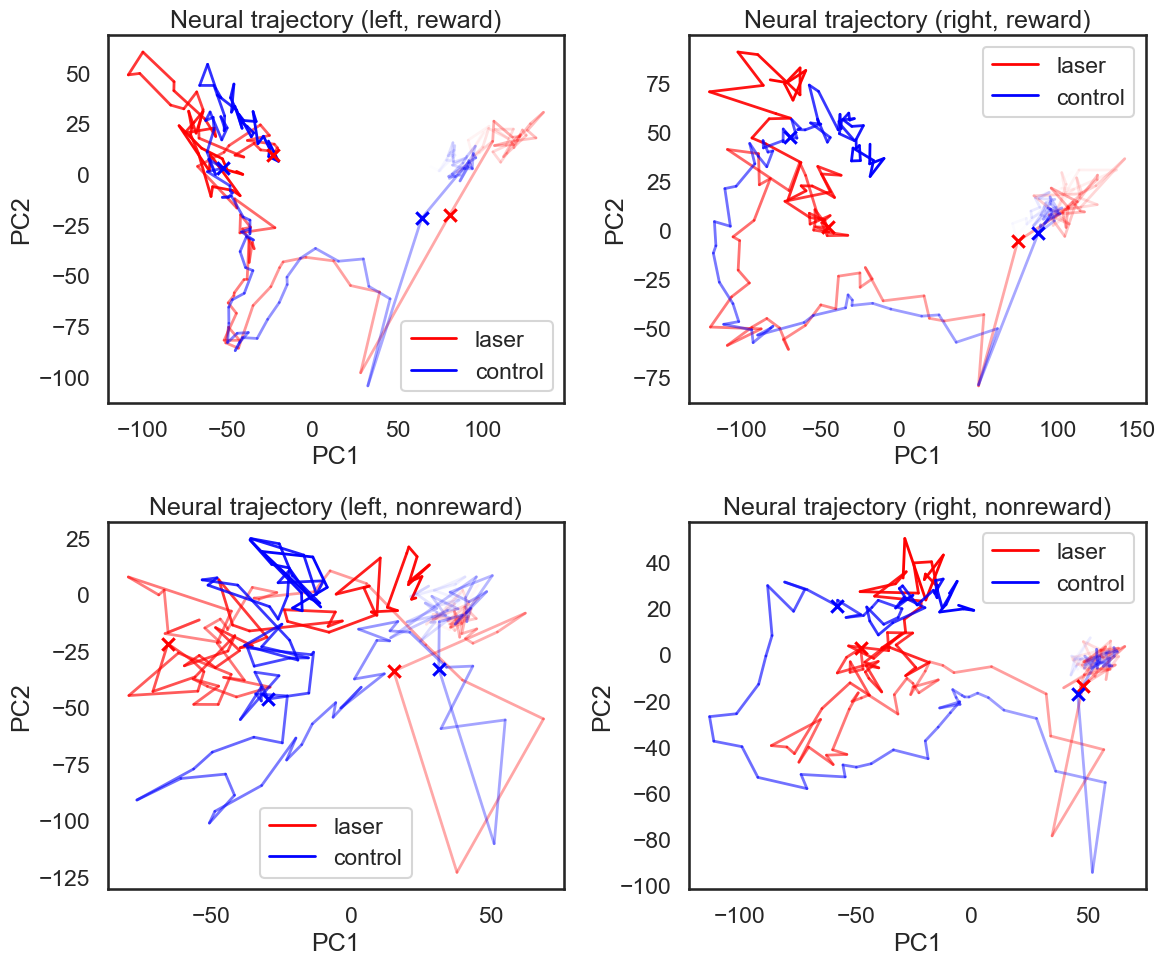

In [19]:
from sklearn.decomposition import PCA

# ─── Generate PCA ───────────────────────────────────────
control_data = ndap.combine_rates(aligned, key=['control'])
control_data = np.nanmean(control_data, axis=1).T
pca_control = PCA(n_components=3).fit(control_data)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
key_time = [0, 1]

# ─── Top‐Left: Left Trials Trajectory ───────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red', ax=axs[0,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[0,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,0].legend()
axs[0,0].set_xlabel('PC1')
axs[0,0].set_ylabel('PC2')
axs[0,0].set_title('Neural trajectory (left, reward)')

# ─── Top‐Right: Right Trials Trajectory ────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[0,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[0,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,1].legend()
axs[0,1].set_xlabel('PC1')
axs[0,1].set_ylabel('PC2')
axs[0,1].set_title('Neural trajectory (right, reward)')

# ─── Bottom‐Left: left no reward trajectory ─────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[1,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[1,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,0].legend()
axs[1,0].set_xlabel('PC1')
axs[1,0].set_ylabel('PC2')
axs[1,0].set_title('Neural trajectory (left, nonreward)')

# ─── Bottom‐Right: right no reward trajectory ───────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[1,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[1,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,1].legend()
axs[1,1].set_xlabel('PC1')
axs[1,1].set_ylabel('PC2')
axs[1,1].set_title('Neural trajectory (right, nonreward)')

plt.tight_layout()
plt.show()


## 4. Decoder analysis

### 4.1. Left and right axis

In [20]:
# Run to get decoder
window_size = 100   # in ms

# Convert to numpy
left_rates_control = ndap.convert_dask_to_numpy(left_rates_control)
right_rates_control = ndap.convert_dask_to_numpy(right_rates_control)
left_rates_laser = ndap.convert_dask_to_numpy(left_rates_laser)
right_rates_laser = ndap.convert_dask_to_numpy(right_rates_laser)

# Get decoders
decoders, accs = ndap.get_decoders(left_rates_control, right_rates_control, 
                                window_size_ms=window_size, bin_size_ms=bin_size, max_iter=10000)

Selected decoder accuracy: 0.9452054794520548


Text(0, 0.5, 'Projection (--> right)')

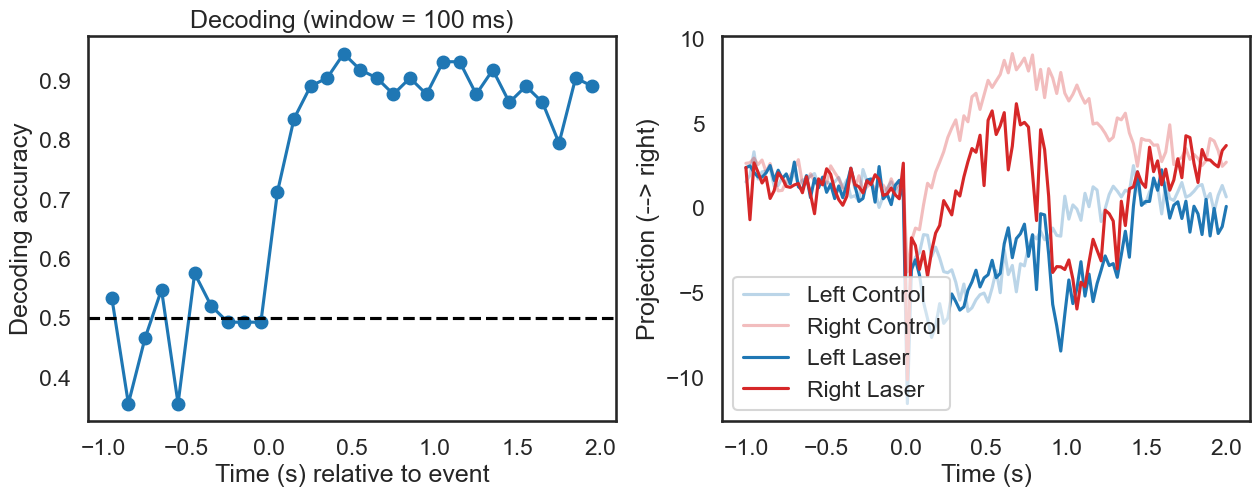

In [21]:
# Select decoder
# Note: -7 to -6, shape looks very different
index = np.argmax(accs)
print('Selected decoder accuracy: ' + str(accs[index]))
decoder_left_right = decoders[index]


fig, axs = plt.subplots(1,2, figsize=(15,5))
# plot accuracy vs. time (bin centers)
# compute time‐bin centers
n_bins = aligned['reward_left_laser']['params']['n_timestep']
window_size_in_bins = max(1, int(round(window_size / bin_size)))
n_windows    = int(np.ceil(n_bins / window_size_in_bins))
time_bins    = np.linspace(time_range[0], time_range[1], n_bins, endpoint=False) + bin_size/1000/2
time_centers = [
    time_bins[i*window_size_in_bins : min((i+1)*window_size_in_bins, n_bins)].mean()
    for i in range(n_windows)
]
# plot
axs[0].plot(time_centers, accs, '-o')
axs[0].axhline(0.5, color='k', linestyle='--')
axs[0].set_xlabel('Time (s) relative to event')
axs[0].set_ylabel('Decoding accuracy')
axs[0].set_title(f'Decoding (window = {window_size} ms)')

# Plot projection
xaxis = np.linspace(time_range[0], time_range[1], n_bins)

left_control_trial_avg = np.nanmean(left_rates_control,axis=1)
right_control_trial_avg = np.nanmean(right_rates_control,axis=1)
proj_left_control = ndap.project(left_control_trial_avg, decoder_left_right)
proj_right_control = ndap.project(right_control_trial_avg, decoder_left_right)

left_laser_trial_avg = np.nanmean(left_rates_laser,axis=1)
right_laser_trial_avg = np.nanmean(right_rates_laser,axis=1)
proj_left_laser = ndap.project(left_laser_trial_avg, decoder_left_right)
proj_right_laser = ndap.project(right_laser_trial_avg, decoder_left_right)

axs[1].plot(xaxis, proj_left_control,  color=left_color,  alpha=alpha_ctrl,  label='Left Control')
axs[1].plot(xaxis, proj_right_control, color=right_color, alpha=alpha_ctrl,  label='Right Control')
axs[1].plot(xaxis, proj_left_laser,    color=left_color,  alpha=alpha_laser, label='Left Laser')
axs[1].plot(xaxis, proj_right_laser,   color=right_color, alpha=alpha_laser, label='Right Laser')

axs[1].legend()
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Projection (--> right)')

Text(0.5, 1.0, 'Spearman ρ = -0.124, p = 0.141')

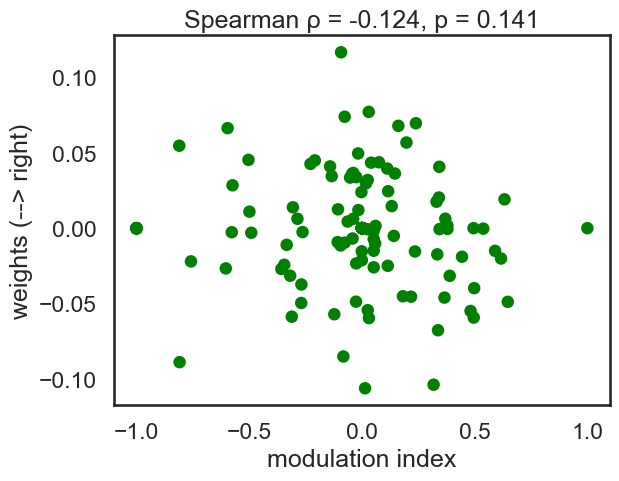

In [22]:
# Correlation of the decoder weights and laser_mod_index
w_units = decoder_left_right.coef_[0]
if criteria is not None: 
    mod_index_included = laser_mod_index[criteria]
else: 
    mod_index_included = laser_mod_index

from scipy.stats import spearmanr
r_spear, p_spear = spearmanr(mod_index_included, w_units)

plt.scatter(mod_index_included, w_units, color='green', edgecolor='None')
plt.xlabel('modulation index')
plt.ylabel('weights (--> right)')
plt.title(f"Spearman ρ = {r_spear:.3f}, p = {p_spear:.3g}")

## 5. rSLDS

### 5.1 Prepare rSLDS data

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_laser', 'reward_left_laser']
Combining 2 conditions: ['nonreward_right_laser', 'reward_right_laser']
[prepare_rslds_data] Data downsampled to 50 ms
[prepare_rslds_data] Data filled with 0 for nan
[prepare_rslds_data] Data z-scored
[prepare_rslds_data] Data downsampled to 50 ms
[prepare_rslds_data] Data filled with 0 for nan
[prepare_rslds_data] Data z-scored
[prepare_rslds_data] Data downsampled to 50 ms
[prepare_rslds_data] Data filled with 0 for nan
[prepare_rslds_data] Data z-scored


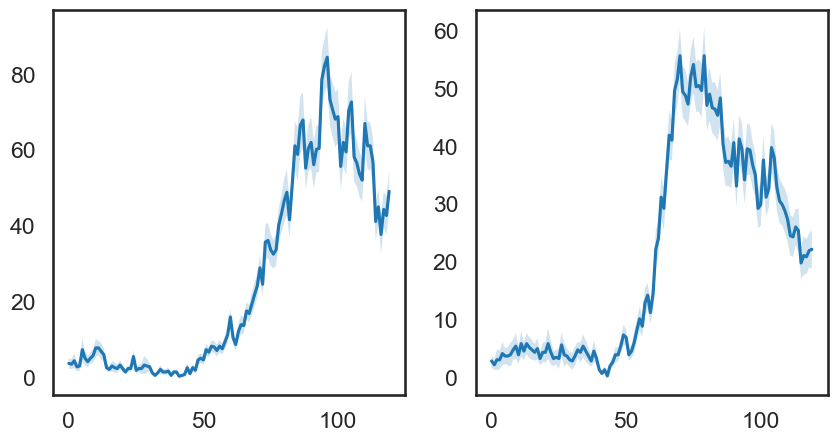

In [5]:
# Define aligned data and time range
aligned = aligned_trial_start
criteria = None
target_bin_size_ms = 50
n_classes = 2

# Combine data
left_rates_control = ndap.combine_rates(aligned, key=['left','control'])
right_rates_control = ndap.combine_rates(aligned, key=['right','control'])
left_rates_laser = ndap.combine_rates(aligned, key=['left','laser'])
right_rates_laser = ndap.combine_rates(aligned, key=['right','laser'])

if criteria is not None:
    left_rates_control = left_rates_control[criteria, :, :]
    right_rates_control = right_rates_control[criteria, :, :]
    left_rates_laser = left_rates_laser[criteria, :, :]
    right_rates_laser = right_rates_laser[criteria, :, :]

# Prepare data for rSLDS
combined_data = np.concatenate([left_rates_control, right_rates_control], axis=1)
type1_label = np.array([[1, 0]] * left_rates_control.shape[1])
type2_label = np.array([[0, 1]] * right_rates_control.shape[1])
trial_types = np.r_[type1_label, type2_label]

rslds_data, inputs = ndap.prepare_rslds_data(combined_data, trial_types=trial_types, n_classes=n_classes,
                                             downsample=True, target_bin_size_ms=target_bin_size_ms, bin_size_ms=bin_size)
left_laser_data, left_laser_inputs = ndap.prepare_rslds_data(left_rates_laser, trial_types=type1_label, n_classes=n_classes,
                                             downsample=True, target_bin_size_ms=target_bin_size_ms, bin_size_ms=bin_size)
right_laser_data, right_laser_inputs = ndap.prepare_rslds_data(right_rates_laser, trial_types=type2_label, n_classes=n_classes,
                                             downsample=True, target_bin_size_ms=target_bin_size_ms, bin_size_ms=bin_size)                                                                                         

# Plot the data
unit_id = 67
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ndap.plot_sem(left_rates_control[unit_id], ax=axes[0])
ndap.plot_sem(right_rates_control[unit_id], ax=axes[1])
plt.show()

### 5.2. Fit a rSLDS model

In [ ]:
# Set rSLDS parameters
n_states = 4         # Number of discrete states (change as appropriate)
n_latent_dims = 2    # Number of latent dimensions (for visualization)
num_iters = 50      # Number of EM iterations

# Fit the rSLDS model
rslds, posterior, elbos = ndap.fit_rslds_model((rslds_data, inputs), n_states=n_states, n_latent_dims=n_latent_dims, num_iters=num_iters, emissions='gaussian')

Initializing model...


In [ ]:
# Save model
save_path = ndap.save_rslds_model(rslds, posterior, (rslds_data, inputs), 
                                file_name="cue_-1to2.joblib", folder_name=session_id,
                                elbos=elbos, time_range=time_range, bin_size=target_bin_size_ms)
print(f"Save rSLDS model to: {save_path}")

Save rSLDS model to: Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001//cue_-1to2.joblib


### 5.3. Plot model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyNeuroDAP as ndap

In [ ]:
# Load model
# if 'save_path' not in locals():
#     save_path = "Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/cue_-1to2.joblib"

save_path = "Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/cue_-1to2.joblib"
B = ndap.load_rslds_model(save_path)
print(f"Load rSLDS model from: {save_path}")

model = B["objects"]["model"]
posterior = B["objects"]["posterior"]
Y = B["data"]["Y_list"]
U = B["data"]["U_list"]
x = B["posterior"]["x_list"][0]
z = B["posterior"]["z_list"][0]
elbos = B["posterior"]["elbos"]
time_range = B["data"]["time_range"]
bin_size = B["data"]["bin_size"]

# Build type1_tuple and type2_tuple from Y and U
type1_tuple, type2_tuple = ndap.separate_rslds_tuple(Y, U)

Load rSLDS model from: Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/cue_-1to2.joblib


In [ ]:
# Optional: save additional stuff
# save_path = ndap.save_rslds_model(model, posterior, (Y, U), 
#                                 file_name="cue_-1to2.joblib", folder_name="Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001",
#                                 elbos=elbos, time_range=time_range, bin_size=50)

Key time (in sec): [-1.0, 0, 0.5]
time_range: (-1.0, 2.0) sec, bin_size: 50 ms


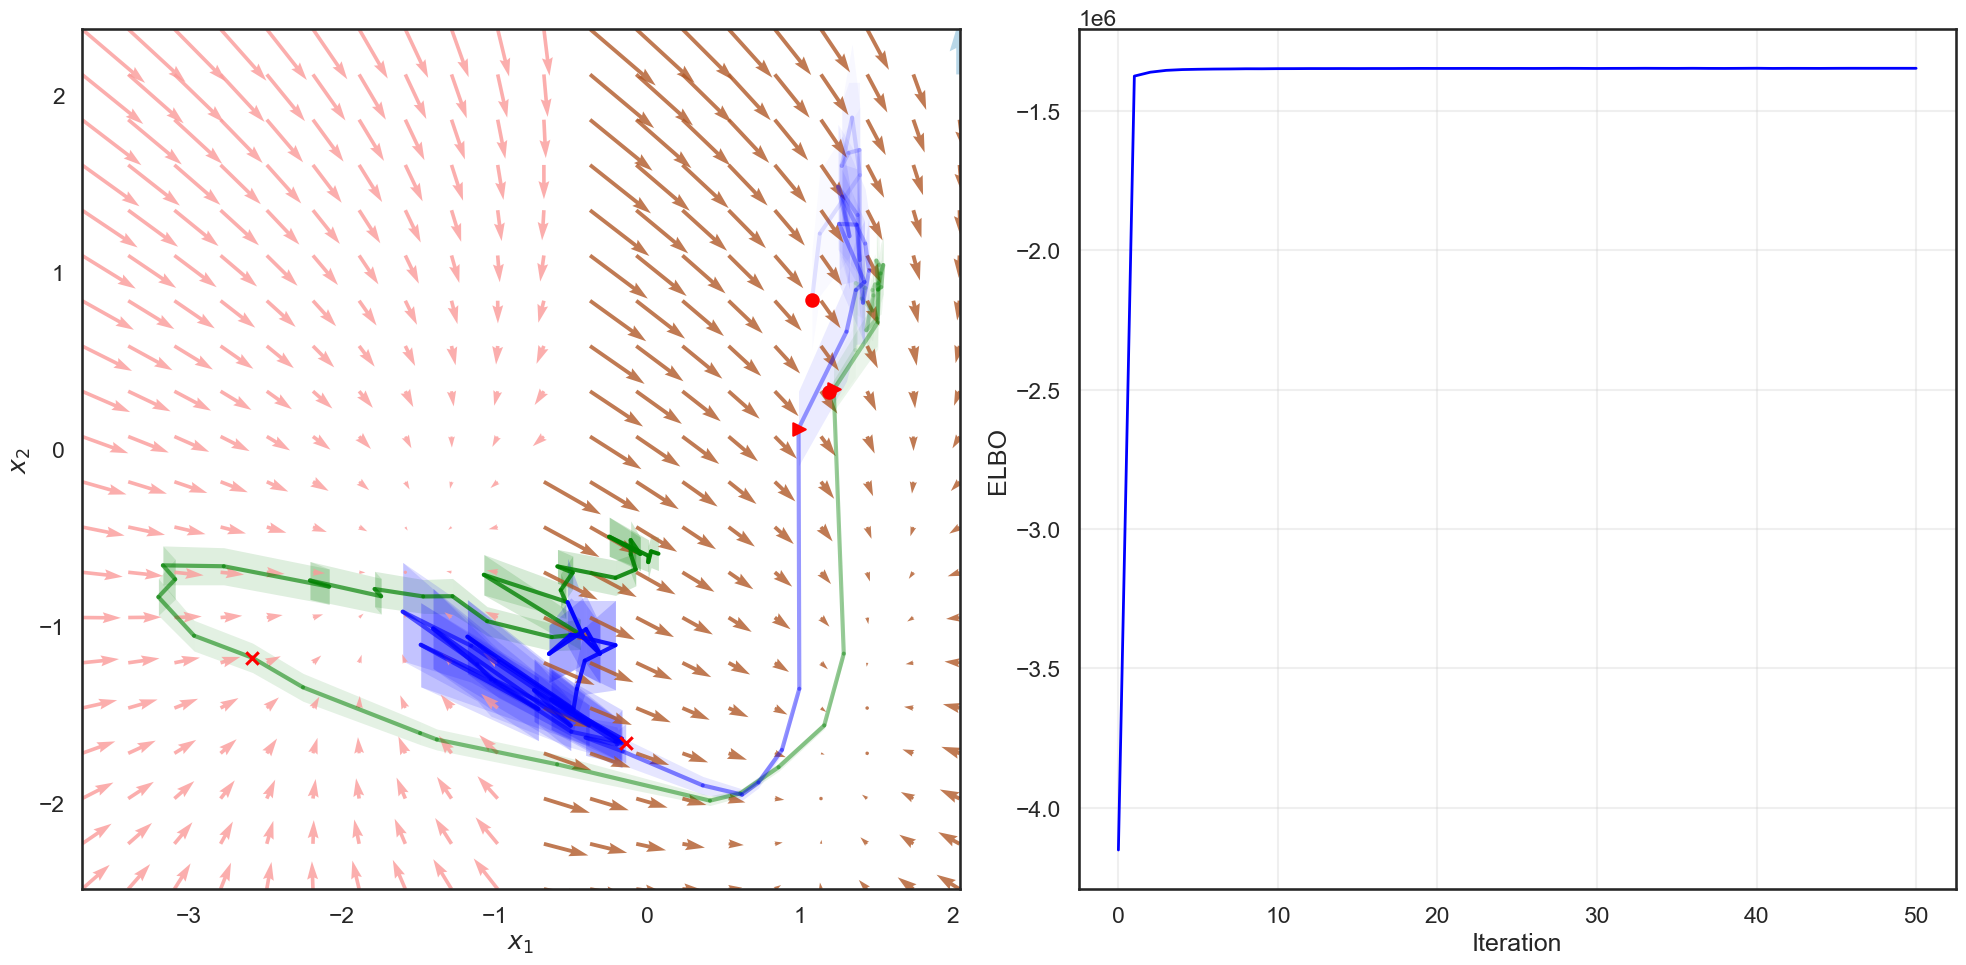

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
key_time = [time_range[0], 0, 0.5]
print(f"Key time (in sec): {key_time}")
print(f"time_range: {time_range} sec, bin_size: {bin_size} ms")

# Select trial indices
t1_idx = None
t2_idx = None

# Vector field / most-likely dynamics
ndap.plot_rslds_trajectory(model, posterior, type1_tuple, ax=axes[0], trial_idx=t1_idx,
                           color="green", key_time=key_time, time_range=time_range, bin_size=bin_size)
ndap.plot_rslds_trajectory(model, posterior, (left_laser_data, left_laser_inputs), ax=axes[0], trial_idx=t1_idx,
                           color="blue", key_time=key_time, time_range=time_range, bin_size=bin_size)
# ndap.plot_rslds_trajectory(model, posterior, type2_tuple, ax=axes[0], trial_idx=t2_idx,
#                            color="purple", key_time=key_time, time_range=time_range, bin_size=bin_size)
# ndap.plot_rslds_trajectory(model, posterior, (right_laser_data, right_laser_inputs), ax=axes[0], trial_idx=t2_idx,
#                            color="orange", key_time=key_time, time_range=time_range, bin_size=bin_size)
ndap.plot_rslds_dynamics(model, ax=axes[0])

# ELBO curve saved in the bundle
ndap.plot_rslds_elbo(elbos, ax=axes[1])

plt.tight_layout()
plt.show()

## Close file

In [ ]:
for f in _open_h5.values():
    try:
        f.close()
    except:
        pass